In [37]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(42)

n_rows = 50000

first_names = [
    "John", "Mary", "James", "Grace", "David",
    "Brian", "Faith", "Kevin", "Mercy", "Peter"
]

last_names = [
    "Mwangi", "Otieno", "Kiptoo", "Wanjiku",
    "Achieng", "Kamau", "Mutua", "Njoroge"
]

names = [
    random.choice(first_names) + " " + random.choice(last_names)
    for _ in range(n_rows)
]

df = pd.DataFrame({
    "Customer_ID": [f"CUST{i}" for i in range(n_rows)],
    "Customer_Name": names,
    "Age": np.random.randint(18, 70, n_rows),
    "Gender": np.random.choice(["Male", "Female"], n_rows),
    "City": np.random.choice(
        ["Nairobi", "Mombasa", "Kisumu", "Nakuru"],
        n_rows
    ),
    "Income": np.random.randint(20000, 500000, n_rows),
    "Purchase_Amount": np.random.randint(100, 50000, n_rows)
})

# Introduce missing values
for col in ["Age", "Gender"]:
    idx = np.random.choice(df.index, 1000)
    df.loc[idx, col] = np.nan

# Introduce duplicates
df = pd.concat([df, df.sample(500)])

# Save
df.to_csv("messy_dataset.csv", index=False)

print(df)

      Customer_ID  Customer_Name   Age Gender     City  Income  \
0           CUST0  Peter Achieng  56.0   Male   Nakuru  231802   
1           CUST1   Brian Kiptoo  69.0   Male   Nakuru  498933   
2           CUST2   Peter Kiptoo  46.0   Male  Mombasa  494414   
3           CUST3    Peter Kamau  32.0   Male  Mombasa  323293   
4           CUST4   Kevin Mwangi  60.0   Male  Mombasa  109292   
...           ...            ...   ...    ...      ...     ...   
18871   CUST18871   Mercy Kiptoo  67.0   Male   Nakuru  163918   
25509   CUST25509     Mary Kamau  37.0   Male  Nairobi  330735   
27840   CUST27840    Kevin Mutua  36.0   Male  Nairobi  164830   
35616   CUST35616  Mercy Njoroge  34.0   Male  Mombasa  263287   
20929   CUST20929   Peter Kiptoo  65.0   Male  Nairobi  157666   

       Purchase_Amount  
0                42448  
1                36109  
2                17888  
3                27981  
4                 3499  
...                ...  
18871            46947  
25509  

In [14]:
#hey friend welcome to my project
#performing EDA1
nulls=df.isnull().sum()
print(nulls)

Customer_ID          0
Customer_Name        0
Age                995
Gender             999
City                 0
Income               0
Purchase_Amount      0
dtype: int64


In [10]:
#performing EDA2
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50500 entries, 0 to 20929
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      50500 non-null  object 
 1   Customer_Name    50500 non-null  object 
 2   Age              49505 non-null  float64
 3   Gender           49501 non-null  object 
 4   City             50500 non-null  object 
 5   Income           50500 non-null  int64  
 6   Purchase_Amount  50500 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 3.1+ MB
None


In [7]:
#dropping duplicates and null values and formatting
df=df.drop_duplicates()
df=df.dropna()
df["Customer_ID"]=df["Customer_ID"].str.replace("CUST","")
print(df)

      Customer_ID  Customer_Name   Age  Gender     City  Income  \
0               0  Faith Achieng  56.0    Male   Nakuru  231802   
1               1    Faith Kamau  69.0    Male   Nakuru  498933   
2               2  David Achieng  46.0    Male  Mombasa  494414   
3               3  James Achieng  32.0    Male  Mombasa  323293   
4               4  Mercy Achieng  60.0    Male  Mombasa  109292   
...           ...            ...   ...     ...      ...     ...   
49995       49995   Brian Kiptoo  66.0  Female  Nairobi  232779   
49996       49996   Mercy Mwangi  35.0  Female   Kisumu  452651   
49997       49997   Mercy Mwangi  28.0  Female   Kisumu  249955   
49998       49998   Faith Kiptoo  59.0  Female   Nakuru  100917   
49999       49999   James Otieno  35.0    Male   Kisumu   79050   

       Purchase_Amount  
0                42448  
1                36109  
2                17888  
3                27981  
4                 3499  
...                ...  
49995            155

City
Kisumu     11957
Mombasa    12046
Nairobi    12168
Nakuru     11873
Name: Customer_ID, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

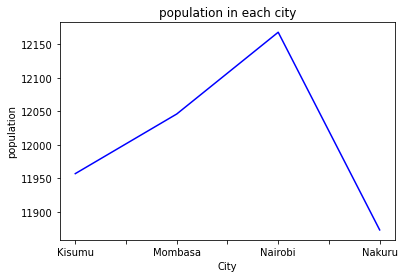

In [20]:
#grouping by city and a visual for easy spotting where we have the highest and smallest no. of customers
df1=df.groupby("City").count()
print(df1["Customer_ID"])
df1["Customer_ID"].plot(kind="line",
                        c="blue",
                        title="population in each city")
plt.ylabel("population")
plt.show

Gender
Female    6499328843
Male      6371103989
Name: Income, dtype: int64


Text(0.5, 0, "population in '000000000")

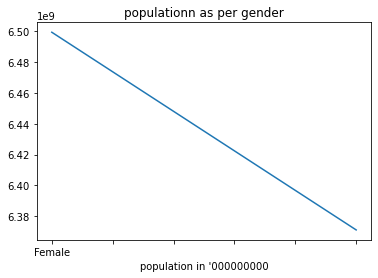

In [39]:
#finding which gender earns more income
df2=df.groupby("Gender").sum()
print(df2["Income"])
df2["Income"].plot(kind="line",
                   title="populationn as per gender")
plt.xlabel("population in '000000000")


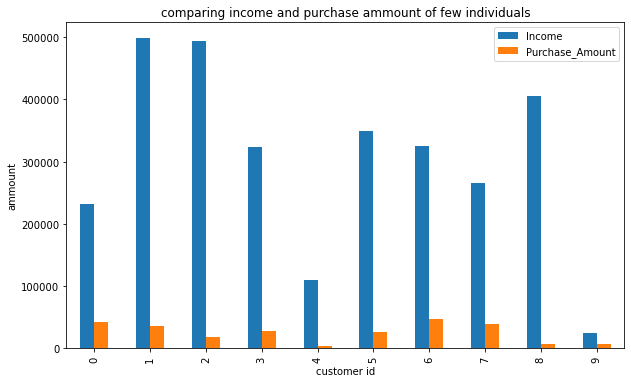

In [38]:
#checking whether the ammount of income affects the Purchase Amount
df3=df.head(10)[["Income","Purchase_Amount"]]
#print(df3)
df3.plot(kind="bar",
         figsize=(10,6),
         title="comparing income and purchase ammount of few individuals")
plt.xlabel("customer id")
plt.ylabel("ammount")

plt.show()